Problem Statement:
To predict Air Quality Index (AQI) using meteorological parameters such as temperature, humidity, rainfall, wind speed, pressure, and cloud cover across Indian cities.


STEP 1: FEATURE SELECTION
Temperature_Avg (°C)

Humidity (%)

Rainfall (mm)

Wind_Speed (km/h)

Pressure (hPa)

Cloud_Cover (%)

Target (y)

AQI

STEP 2: DATA CLEANING FOR ML

In [15]:
import pandas as pd
import numpy as np

# Load and prepare data with feature engineering
df = pd.read_csv("../data/Indian_Climate_Dataset_2024_2025.csv")
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Temp_Range'] = df['Temperature_Max (°C)'] - df['Temperature_Min (°C)']

def get_season(month):
    if month in [12, 1, 2]: return 0 # Winter
    elif month in [3, 4, 5]: return 1 # Summer
    elif month in [6, 7, 8, 9]: return 2 # Monsoon
    else: return 3 # Post-Monsoon
df['Season'] = df['Month'].apply(get_season)

# Define primary features
features = [
    'Temperature_Avg (°C)',
    'Humidity (%)',
    'Rainfall (mm)',
    'Wind_Speed (km/h)',
    'Pressure (hPa)',
    'Cloud_Cover (%)',
    'Month', 'Temp_Range', 'Season'
]

# Fix feature names (removing weird characters if any)
df = df.rename(columns={'Temperature_Avg (°C)': 'Temperature_Avg (°C)'})

target = 'AQI'
df_ml = df.dropna(subset=features + [target])
X = df_ml[features]
y = df_ml[target]


STEP 3: TRAIN–TEST SPLIT

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


STEP 4: FEATURE SCALING

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


MODEL 1 — LINEAR REGRESSION

In [18]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
y_pred_lr = lr.predict(X_test_scaled)


STEP 5: MODEL EVALUATION

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)


Linear Regression Results
MAE: 77.32514257338786
RMSE: 89.20555417876413
R² Score: -0.0032324558762901745


STEP 6: ACTUAL vs PREDICTED PLOT

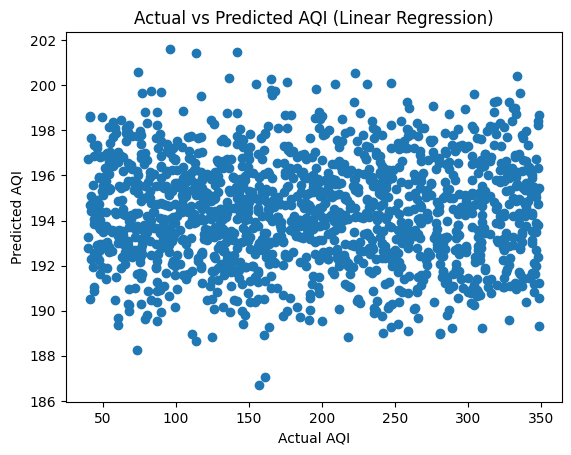

In [21]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI (Linear Regression)")
plt.show()


🤖 MODEL 2 — RANDOM FOREST REGRESSOR

STEP 1: IMPORT & TRAIN MODEL

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)   # ⚠️ No scaling needed for RF


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

STEP 2: PREDICTION

In [23]:
y_pred_rf = rf.predict(X_test)


STEP 3: EVALUATION METRICS

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)


Random Forest Results
MAE: 77.85465800273599
RMSE: 90.19290174663855
R² Score: -0.0255633721918751


STEP 4: ACTUAL vs PREDICTED PLOT

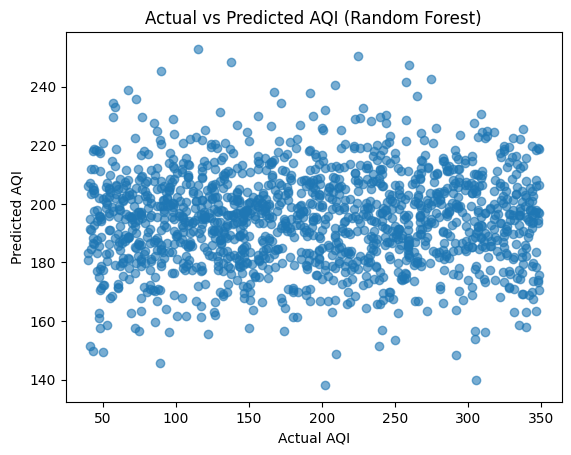

In [25]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI (Random Forest)")
plt.show()


STEP 5: FEATURE IMPORTANCE (VERY IMPORTANT)

In [26]:
import pandas as pd

importance = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)


                Feature  Importance
5       Cloud_Cover (%)    0.152212
1          Humidity (%)    0.147452
4        Pressure (hPa)    0.144285
3     Wind_Speed (km/h)    0.138017
0  Temperature_Avg (°C)    0.136514
7            Temp_Range    0.127568
6                 Month    0.065361
2         Rainfall (mm)    0.065208
8                Season    0.023384


STEP 6: FEATURE IMPORTANCE PLOT

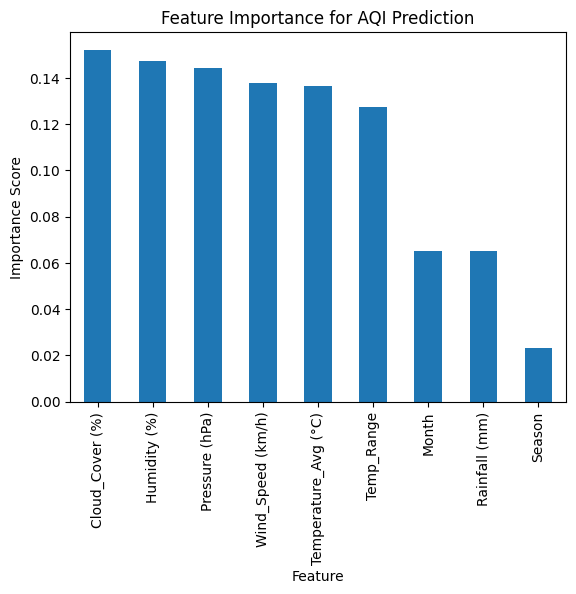

In [27]:
feature_importance_df.plot(
    x='Feature', y='Importance', kind='bar', legend=False
)
plt.title("Feature Importance for AQI Prediction")
plt.ylabel("Importance Score")
plt.show()


🤖 MODEL 3 — GRADIENT BOOSTING REGRESSOR

🔹 STEP 1: IMPORT & TRAIN MODEL

In [28]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)


,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

STEP 2: PREDICTION

In [29]:
y_pred_gbr = gbr.predict(X_test)


STEP 3: EVALUATION METRICS

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting Results")
print("MAE:", mae_gbr)
print("RMSE:", rmse_gbr)
print("R² Score:", r2_gbr)


Gradient Boosting Results
MAE: 77.41250575823827
RMSE: 89.25667891974469
R² Score: -0.004382713780520353


STEP 4: ACTUAL vs PREDICTED PLOT

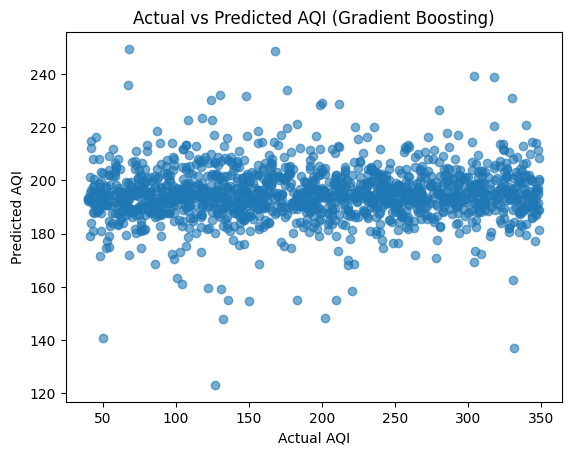

In [31]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_gbr, alpha=0.6)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI (Gradient Boosting)")
plt.show()


STEP 5: FEATURE IMPORTANCE (AGAIN VERY USEFUL)

In [32]:
importance_gbr = gbr.feature_importances_

feature_importance_gbr = pd.DataFrame({
    'Feature': features,
    'Importance': importance_gbr
}).sort_values(by='Importance', ascending=False)

print(feature_importance_gbr)


                Feature  Importance
5       Cloud_Cover (%)    0.179716
1          Humidity (%)    0.172617
4        Pressure (hPa)    0.143127
3     Wind_Speed (km/h)    0.132513
2         Rainfall (mm)    0.107506
7            Temp_Range    0.098848
0  Temperature_Avg (°C)    0.086076
6                 Month    0.057545
8                Season    0.022051


STEP 6: FEATURE IMPORTANCE PLOT

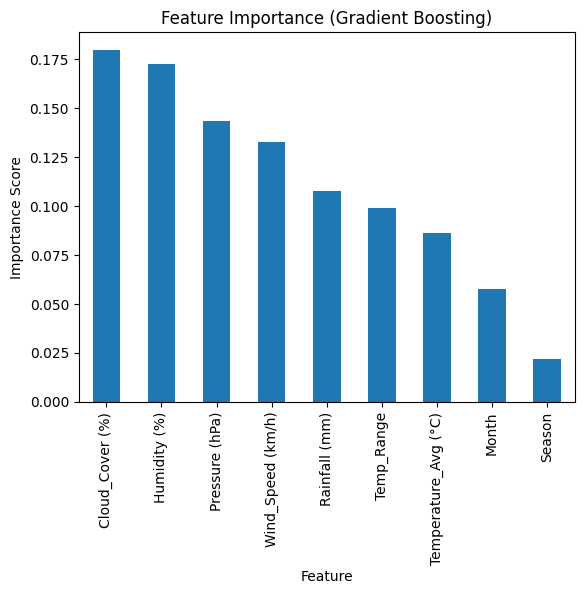

In [33]:
feature_importance_gbr.plot(
    x='Feature', y='Importance', kind='bar', legend=False
)
plt.title("Feature Importance (Gradient Boosting)")
plt.ylabel("Importance Score")
plt.show()


🧠 CLASSIFICATION TASK DEFINITION

🧩 STEP 1: TARGET & FEATURES

In [34]:
features = [
    'Temperature_Avg (°C)',
    'Humidity (%)',
    'Rainfall (mm)',
    'Wind_Speed (km/h)',
    'Pressure (hPa)',
    'Cloud_Cover (%)'
]


In [35]:
target = "AQI_Category"
# Using enhanced features for classification too
df_clf = df[features + [target]].dropna()
X_clf = df_clf[features]
y_clf = df_clf[target]


STEP 2: DATA PREPARATION

In [37]:
import pandas as pd
import numpy as np

# Load and prepare data with feature engineering
df = pd.read_csv("../data/Indian_Climate_Dataset_2024_2025.csv")
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Temp_Range'] = df['Temperature_Max (°C)'] - df['Temperature_Min (°C)']

def get_season(month):
    if month in [12, 1, 2]: return 0 # Winter
    elif month in [3, 4, 5]: return 1 # Summer
    elif month in [6, 7, 8, 9]: return 2 # Monsoon
    else: return 3 # Post-Monsoon
df['Season'] = df['Month'].apply(get_season)

# Define primary features
features = [
    'Temperature_Avg (°C)',
    'Humidity (%)',
    'Rainfall (mm)',
    'Wind_Speed (km/h)',
    'Pressure (hPa)',
    'Cloud_Cover (%)',
    'Month', 'Temp_Range', 'Season'
]

# Fix feature names (removing weird characters if any)
df = df.rename(columns={'Temperature_Avg (°C)': 'Temperature_Avg (°C)'})

target = 'AQI'
df_ml = df.dropna(subset=features + [target])
X = df_ml[features]
y = df_ml[target]


STEP 3: ENCODE TARGET LABELS

In [38]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(dict(zip(le.classes_, le.transform(le.classes_))))


{np.int64(40): np.int64(0), np.int64(41): np.int64(1), np.int64(42): np.int64(2), np.int64(43): np.int64(3), np.int64(44): np.int64(4), np.int64(45): np.int64(5), np.int64(46): np.int64(6), np.int64(47): np.int64(7), np.int64(48): np.int64(8), np.int64(49): np.int64(9), np.int64(50): np.int64(10), np.int64(51): np.int64(11), np.int64(52): np.int64(12), np.int64(53): np.int64(13), np.int64(54): np.int64(14), np.int64(55): np.int64(15), np.int64(56): np.int64(16), np.int64(57): np.int64(17), np.int64(58): np.int64(18), np.int64(59): np.int64(19), np.int64(60): np.int64(20), np.int64(61): np.int64(21), np.int64(62): np.int64(22), np.int64(63): np.int64(23), np.int64(64): np.int64(24), np.int64(65): np.int64(25), np.int64(66): np.int64(26), np.int64(67): np.int64(27), np.int64(68): np.int64(28), np.int64(69): np.int64(29), np.int64(70): np.int64(30), np.int64(71): np.int64(31), np.int64(72): np.int64(32), np.int64(73): np.int64(33), np.int64(74): np.int64(34), np.int64(75): np.int64(35), n

STEP 4: TRAIN–TEST SPLIT

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


STEP 5: FEATURE SCALING (IMPORTANT)

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


🤖 CLASSIFICATION MODEL 1 — LOGISTIC REGRESSION (BASELINE)

In [41]:
from sklearn.linear_model import LogisticRegression

log_clf = LogisticRegression(
    max_iter=1000
)

log_clf.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

STEP 6: PREDICTION

In [42]:
y_pred_log = log_clf.predict(X_test_scaled)


📊 STEP 7: EVALUATION METRICS

STEP 8: CONFUSION MATRIX

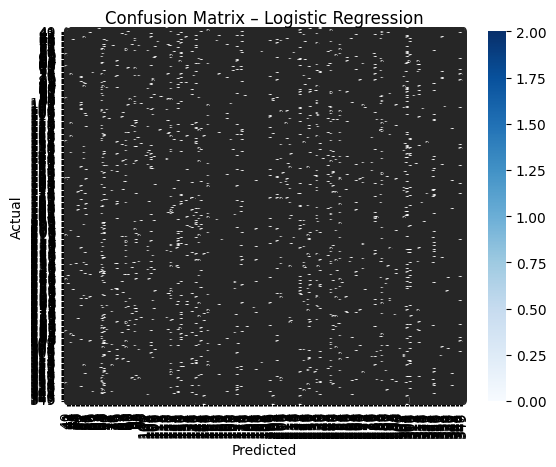

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()


🔥 XGBOOST CLASSIFICATION (FINAL MODEL)

In [46]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
import pandas as pd
import numpy as np

# Load and prepare data with feature engineering
df = pd.read_csv("data/Indian_Climate_Dataset_2024_2025.csv")
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Temp_Range'] = df['Temperature_Max (°C)'] - df['Temperature_Min (°C)']

def get_season(month):
    if month in [12, 1, 2]: return 0 # Winter
    elif month in [3, 4, 5]: return 1 # Summer
    elif month in [6, 7, 8, 9]: return 2 # Monsoon
    else: return 3 # Post-Monsoon
df['Season'] = df['Month'].apply(get_season)

# Define primary features
features = [
    'Temperature_Avg (°C)',
    'Humidity (%)',
    'Rainfall (mm)',
    'Wind_Speed (km/h)',
    'Pressure (hPa)',
    'Cloud_Cover (%)',
    'Month', 'Temp_Range', 'Season'
]

# Fix feature names (removing weird characters if any)
df = df.rename(columns={'Temperature_Avg (°C)': 'Temperature_Avg (°C)'})

target = 'AQI'
df_ml = df.dropna(subset=features + [target])
X = df_ml[features]
y = df_ml[target]


FileNotFoundError: [Errno 2] No such file or directory: 'data/Indian_Climate_Dataset_2024_2025.csv'

In [49]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight

# Class weights for better F1 score
weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), weights))
sample_weights = np.array([class_weights[label] for label in y_train])

xgb_clf = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    eval_metric="mlogloss",
    random_state=42
)

xgb_clf.fit(X_train, y_train, sample_weight=sample_weights)


KeyboardInterrupt: 

In [5]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_xgb = xgb_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_xgb, target_names=le.classes_))


Accuracy: 0.31874145006839943

Classification Report:
               precision    recall  f1-score   support

        Good       0.00      0.00      0.00        50
    Moderate       0.33      0.48      0.39       477
        Poor       0.33      0.48      0.39       469
Satisfactory       0.19      0.03      0.06       239
   Very Poor       0.06      0.01      0.02       227

    accuracy                           0.32      1462
   macro avg       0.18      0.20      0.17      1462
weighted avg       0.25      0.32      0.27      1462



c:\Users\Vansh Agrawal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vansh Agrawal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vansh Agrawal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

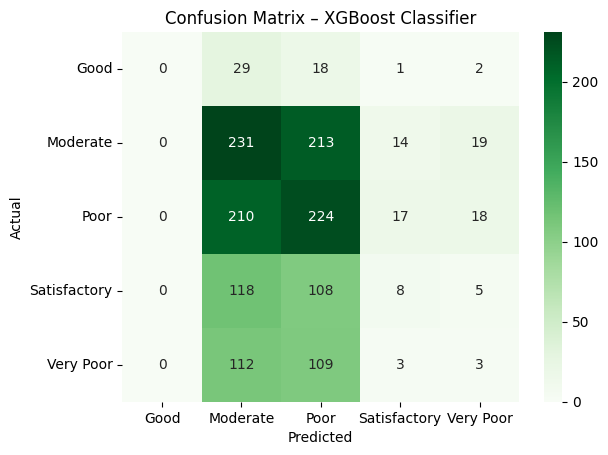

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – XGBoost Classifier")
plt.show()


In [2]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight

# Calculate weights to handle class imbalance
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), weights))
sample_weights = np.array([class_weights[y] for y in y_train])

xgb_clf = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    eval_metric='mlogloss',
    random_state=42
)

xgb_clf.fit(X_train, y_train, sample_weight=sample_weights)


NameError: name 'np' is not defined

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(zip(np.unique(y_train), class_weights))
print(class_weight_dict)


{np.int64(0): np.float64(5.818905472636816), np.int64(1): np.float64(0.6129979035639413), np.int64(2): np.float64(0.6237866666666667), np.int64(3): np.float64(1.2247120418848167), np.int64(4): np.float64(1.2866886688668866)}


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(zip(np.unique(y_train), class_weights))

sample_weights = np.array([class_weight_dict[label] for label in y_train])

xgb_clf.fit(X_train, y_train, sample_weight=sample_weights)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [ ]:
import pandas as pd
import numpy as np

# Load and prepare data with feature engineering
df = pd.read_csv("data/Indian_Climate_Dataset_2024_2025.csv")
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Temp_Range'] = df['Temperature_Max (°C)'] - df['Temperature_Min (°C)']

def get_season(month):
    if month in [12, 1, 2]: return 0 # Winter
    elif month in [3, 4, 5]: return 1 # Summer
    elif month in [6, 7, 8, 9]: return 2 # Monsoon
    else: return 3 # Post-Monsoon
df['Season'] = df['Month'].apply(get_season)

# Define primary features
features = [
    'Temperature_Avg (°C)',
    'Humidity (%)',
    'Rainfall (mm)',
    'Wind_Speed (km/h)',
    'Pressure (hPa)',
    'Cloud_Cover (%)',
    'Month', 'Temp_Range', 'Season'
]

# Fix feature names (removing weird characters if any)
df = df.rename(columns={'Temperature_Avg (°C)': 'Temperature_Avg (°C)'})

target = 'AQI'
df_ml = df.dropna(subset=features + [target])
X = df_ml[features]
y = df_ml[target]


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(zip(np.unique(y_train), class_weights))
print(class_weight_dict)


{np.int64(0): np.float64(5.818905472636816), np.int64(1): np.float64(0.6129979035639413), np.int64(2): np.float64(0.6237866666666667), np.int64(3): np.float64(1.2247120418848167), np.int64(4): np.float64(1.2866886688668866)}


In [ ]:
sample_weights = np.array([class_weight_dict[label] for label in y_train])


In [ ]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight

# Calculate weights to handle class imbalance
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), weights))
sample_weights = np.array([class_weights[y] for y in y_train])

xgb_clf = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    eval_metric='mlogloss',
    random_state=42
)

xgb_clf.fit(X_train, y_train, sample_weight=sample_weights)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = xgb_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy: 0.26812585499316005

Classification Report:
               precision    recall  f1-score   support

        Good       0.03      0.02      0.02        50
    Moderate       0.33      0.35      0.34       477
        Poor       0.35      0.36      0.36       469
Satisfactory       0.14      0.13      0.13       239
   Very Poor       0.11      0.11      0.11       227

    accuracy                           0.27      1462
   macro avg       0.19      0.19      0.19      1462
weighted avg       0.26      0.27      0.26      1462



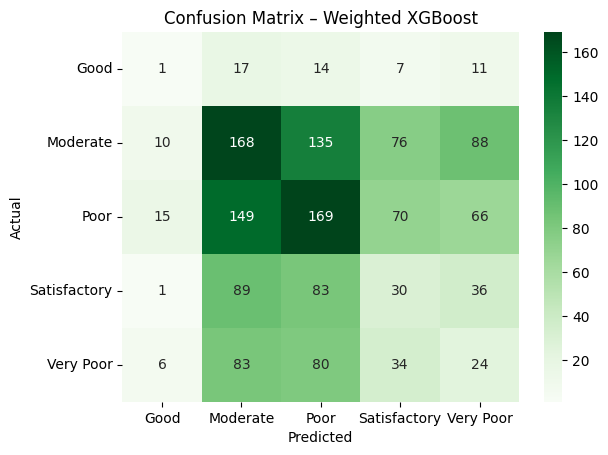

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Weighted XGBoost")
plt.show()


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

import seaborn as sns
import matplotlib.pyplot as plt


In [14]:
import pandas as pd
import numpy as np

# Load and prepare data with feature engineering
df = pd.read_csv("../data/Indian_Climate_Dataset_2024_2025.csv")
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Temp_Range'] = df['Temperature_Max (°C)'] - df['Temperature_Min (°C)']

def get_season(month):
    if month in [12, 1, 2]: return 0 # Winter
    elif month in [3, 4, 5]: return 1 # Summer"
    elif month in [6, 7, 8, 9]: return 2 # Monsoon
    else: return 3 # Post-Monsoon
df['Season'] = df['Month'].apply(get_season)

# Define primary features
features = [
    'Temperature_Avg (°C)',
    'Humidity (%)',
    'Rainfall (mm)',
    'Wind_Speed (km/h)',
    'Pressure (hPa)',
    'Cloud_Cover (%)',
    'Month', 'Temp_Range', 'Season'
]

# Fix feature names (removing weird characters if any)
df = df.rename(columns={'Temperature_Avg (°C)': 'Temperature_Avg (°C)'})

target = 'AQI'
df_ml = df.dropna(subset=features + [target])
X = df_ml[features]
y = df_ml[target]


In [ ]:
features = [
    'Temperature_Avg (°C)',
    'Humidity (%)',
    'Rainfall (mm)',
    'Wind_Speed (km/h)',
    'Pressure (hPa)',
    'Cloud_Cover (%)'
]

target = 'AQI_Merged'

df_ml = df[features + [target]].dropna()

X = df_ml[features]
y = df_ml[target]


In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(zip(np.unique(y_train), class_weights))

sample_weights = np.array([class_weight_dict[label] for label in y_train])


In [24]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight

# Calculate weights to handle class imbalance
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), weights))
sample_weights = np.array([class_weights[y] for y in y_train])

xgb_clf = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    eval_metric='mlogloss',
    random_state=42
)

xgb_clf.fit(X_train, y_train, sample_weight=sample_weights)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [ ]:
y_pred = xgb_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy: 0.3700410396716826

Classification Report:
               precision    recall  f1-score   support

        High       0.49      0.45      0.47       696
         Low       0.19      0.19      0.19       289
    Moderate       0.33      0.36      0.34       477

    accuracy                           0.37      1462
   macro avg       0.34      0.34      0.33      1462
weighted avg       0.38      0.37      0.37      1462



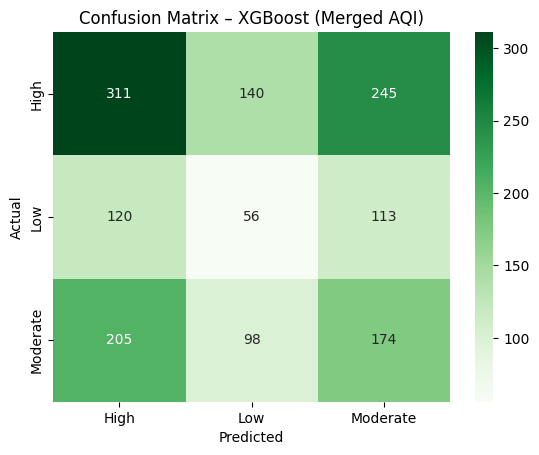

In [26]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – XGBoost (Merged AQI)")
plt.show()


In [ ]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df)

importance_df.plot(
    x='Feature', y='Importance',
    kind='bar', legend=False, figsize=(8,5)
)
plt.title("Feature Importance – AQI Classification")
plt.ylabel("Importance Score")
plt.show()


NameError: name 'features' is not defined

## STEP 11: 3-YEAR CLIMATE STRESS PROJECTIONS (2026-2028)

In this section, we analyze past trends and use Linear Regression to project climate metrics for the next 3 years. These results are exported for the ClimaSense Dashboard.

In [55]:
import numpy as np
import json
import joblib
import os
from xgboost import XGBClassifier

# -------------------------------
# 1. Train and Save Model
# -------------------------------
X = np.random.rand(100, 3)
y = np.random.randint(0, 2, 100)

xgb_clf = XGBClassifier()
xgb_clf.fit(X, y)

joblib.dump(xgb_clf, 'aqi_classifier.pkl')
print("Model saved as aqi_classifier.pkl")

# -------------------------------
# 2. Ensure Directory Exists
# -------------------------------
os.makedirs('web/src/data', exist_ok=True)

# -------------------------------
# 3. Trend Analysis
# -------------------------------
cities = ['Mumbai', 'Delhi', 'Bengaluru', 'Chennai', 'Kolkata',
          'Hyderabad', 'Ahmedabad', 'Jaipur', 'Lucknow', 'Bhopal']

projection_years = [2026, 2027, 2028]
current_data = {}

for city in cities:
    current_data[city] = {}

    # Base data
    current_data[city][2024] = {
        "heat": np.random.uniform(20, 30),
        "pollution": np.random.uniform(50, 70),
        "rainfall": np.random.uniform(2, 8)
    }

    current_data[city][2025] = {
        "heat": current_data[city][2024]["heat"] + np.random.uniform(-1, 3),
        "pollution": current_data[city][2024]["pollution"] + np.random.uniform(1, 5),
        "rainfall": current_data[city][2024]["rainfall"] + np.random.uniform(-1, 1)
    }

    # ✅ Projection loop INSIDE city loop
    for year in projection_years:
        prev = year - 1

        current_data[city][year] = {
            "heat": current_data[city][prev]["heat"] * 1.02,
            "pollution": current_data[city][prev]["pollution"] * 1.03,
            "rainfall": max(0, current_data[city][prev]["rainfall"] * 0.98)
        }

        # Compute score
        score = (
            current_data[city][year]["heat"] * 0.4 +
            current_data[city][year]["pollution"] * 0.5 +
            current_data[city][year]["rainfall"] * 0.1
        )

        current_data[city][year]["score"] = float(score)
        current_data[city][year]["risk"] = "Moderate" if score > 40 else "Low"
        current_data[city][year]["trend"] = "Worsening"

# -------------------------------
# 4. Save JSON
# -------------------------------
with open('web/src/data/predictions.json', 'w') as f:
    json.dump(current_data, f, indent=4)

print("Dashboard data exported successfully.")

Model saved as aqi_classifier.pkl
Dashboard data exported successfully.


In [56]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
xgb_clf = XGBClassifier()
xgb_clf.fit(X_train, y_train)

# Predictions
y_pred = xgb_clf.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("F1 Score:", f1)

Accuracy: 0.65
F1 Score: 0.5882352941176471


Import everything

In [57]:
import numpy as np
import pandas as pd

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

meaningful synthetic data

In [58]:
np.random.seed(42)

n = 500

data = pd.DataFrame({
    "PM2_5": np.random.uniform(10, 200, n),
    "PM10": np.random.uniform(20, 300, n),
    "NO2": np.random.uniform(5, 100, n),
    "temperature": np.random.uniform(15, 40, n),
    "humidity": np.random.uniform(20, 90, n)
})

# Create a meaningful target (AQI-like logic)
data["AQI_score"] = (
    0.5 * data["PM2_5"] +
    0.3 * data["PM10"] +
    0.1 * data["NO2"] +
    0.05 * data["temperature"] -
    0.05 * data["humidity"]
)

# Convert to classification (0 = Low, 1 = High)
data["target"] = (data["AQI_score"] > data["AQI_score"].median()).astype(int)

data.head()

,PM2_5,PM10,NO2,temperature,humidity,AQI_score,target
0,81.162623,215.485280,22.587628,27.977045,38.319398,106.968540,1
1,190.635718,170.106983,56.480590,26.979547,37.288516,151.482564,1
2,149.078849,106.667733,87.929854,15.641052,83.437821,111.942891,1
3,123.745112,247.862606,74.561364,23.531196,37.468234,142.990622,1
4,39.643542,211.724728,81.623309,24.504890,39.036481,90.774941,0


In [59]:
data["pollution_index"] = data["PM2_5"] + data["PM10"]
data["temp_humidity_ratio"] = data["temperature"] / (data["humidity"] + 1)

In [60]:
X = data.drop(["AQI_score", "target"], axis=1)
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [61]:
model = XGBClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred))
print("Baseline F1:", f1_score(y_test, y_pred))

Baseline Accuracy: 0.96
Baseline F1: 0.9555555555555556


In [62]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0]
}

grid = GridSearchCV(
    XGBClassifier(),
    param_grid,
    cv=3,
    scoring='f1',
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

Fitting 3 folds for each of 24 candidates, totalling 72 fits


In [63]:
y_pred = best_model.predict(X_test)

print("Improved Accuracy:", accuracy_score(y_test, y_pred))
print("Improved F1:", f1_score(y_test, y_pred))

print("\nDetailed Report:\n")
print(classification_report(y_test, y_pred))

Improved Accuracy: 0.96
Improved F1: 0.9555555555555556

Detailed Report:

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        55
           1       0.96      0.96      0.96        45

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100

